# Problem 6.2

## Part 0

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Create Lagrange interpolation function

# xnodes and ynodes are lists, x is where we are interpolating
def Lagrange(xnodes, ynodes, x):
    # Add up all the yiLi
    sum = 0

    # Robust portion, make sure that xnodes and ynodes have same length
    if len(xnodes) != len(ynodes):
        raise ValueError("xnodes and ynodes must have the same length")
    
    # Iterate through the range of xnodes
    for i in range(len(xnodes)):

        # Starting value for Lagrange basis functions
        Li = 1

        for j in range(len(xnodes)):
            # In the case when i and j are equal, they look at the same xnode
            if i == j:
                continue

            # Numerator of the Lagrange basis function
            numerator = x - xnodes[j]
            denominator = xnodes[i] - xnodes[j]

            Li = Li * (numerator / denominator)
    
        # Add up all products of the Lagrange basis functions and y
        sum = sum + ynodes[i] * Li

    return sum


## Part 1

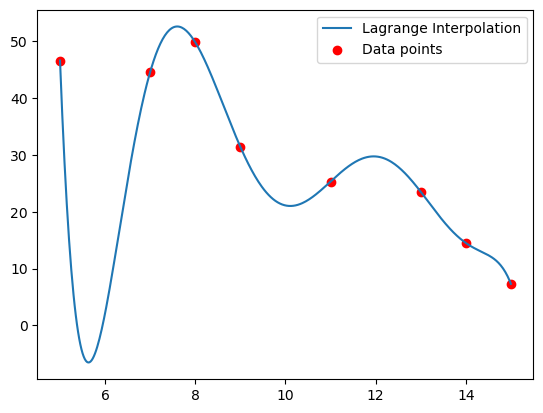

In [9]:
# Plot y = Lagrange and plot each point

# Initialize xnodes and ynodes
xnodes = [5,7,8,9,11,13,14,15]
ynodes = [46.6,44.6,49.8,31.4,25.3,23.5,14.5,7.3]

# Linespace: starting, ending, number of points
x = np.linspace(5, 15, 401)
y = Lagrange(xnodes, ynodes, x)

plt.plot(x, y, label="Lagrange Interpolation")
plt.scatter(xnodes, ynodes, color="red", label="Data points")
plt.legend()


## Part 2

In [30]:
# Using the interpolating polynomial, estimate the average daily temperature for:
# Feb. 1, 4, 6, 10, 12, 16, 18, March 1

# Recall february has 28 days, so march 1 is 29
x_interpolate = [1,4,6,10,12,16,18,29]

# Let y_interpolate be the list of interpolated values
y_interpolate = [Lagrange(xnodes, ynodes, x) for x in x_interpolate]

# Print each value 
for i, value in enumerate(y_interpolate):
    if x_interpolate[i] == 29:
        print(f"Date: March 1, Predicted: {value:.2f}")
    else:
        print(f"Date: February {x_interpolate[i]}, Predicted: {value:.2f}°F")

Date: February 1, Predicted: 24919.90°F
Date: February 4, Predicted: 664.21°F
Date: February 6, Predicted: 2.16°F
Date: February 10, Predicted: 21.10°F
Date: February 12, Predicted: 29.72°F
Date: February 16, Predicted: -84.44°F
Date: February 18, Predicted: -2534.14°F
Date: March 1, Predicted: -3405976.70


## Part 3

In [ ]:
# Calculate errors
actual = [44.3,57.3,45.6,28.6,23.2,17.5,25.3,50.4]

# Recall from 5 to 15
for i in range(len(actual)):
    if 5 <= x_interpolate[i] <= 15:
        print(f"Interpolation error (inside 5 to 15): {actual[i]-y_interpolate[i]:.2f}")
    else:
        print(f"Extrapolation error (outside 5 to 15): {actual[i]-y_interpolate[i]:.2f}")

Error y_actual - y_interpolated: -24875.599999999984
Error y_actual - y_interpolated: -606.9062500000001
Error y_actual - y_interpolated: 43.43749999999998
Error y_actual - y_interpolated: 7.502678571428564
Error y_actual - y_interpolated: -6.518750000000001
Error y_actual - y_interpolated: 101.93749999999994
Error y_actual - y_interpolated: 2559.4437499999985
Error y_actual - y_interpolated: 3406027.1000000006


Interpolation within the data range, from 5 to 15, gives relatively reasonable estimates. Extrapolation outside this range produces large errors because the Lagrange polynomial can change rapidly beyond the known data points.

## Part 4

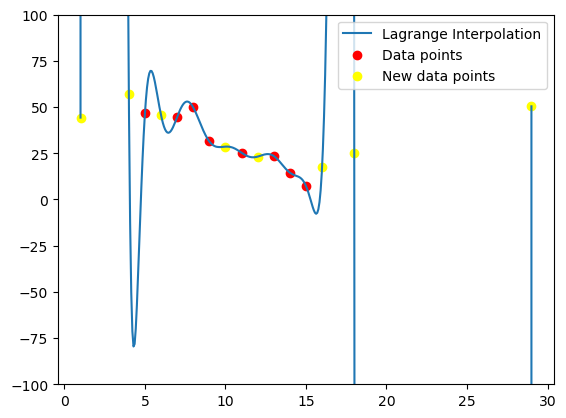

In [28]:
# Extend the plot to cover the interval [1,29]

# Plot y = Lagrange and plot each point

# Initialize xnodes and ynodes
xnodes = [5,7,8,9,11,13,14,15]
ynodes = [46.6,44.6,49.8,31.4,25.3,23.5,14.5,7.3]

# New data points
x_interpolate = [1,4,6,10,12,16,18,29]
actual = [44.3,57.3,45.6,28.6,23.2,17.5,25.3,50.4]

# Combine the old and new data points
new_xnodes = xnodes + x_interpolate
new_ynodes = ynodes + actual

# Linespace: starting, ending, number of points
x = np.linspace(1, 29, 401)
y = Lagrange(new_xnodes, new_ynodes, x)

plt.plot(x, y, label="Lagrange Interpolation")
plt.scatter(xnodes, ynodes, color="red", label="Data points")
plt.scatter(x_interpolate, actual, color="yellow", label="New data points")
plt.ylim(-100, 100)
plt.legend()

The extended plot shows large oscillations near February 1 ($x=1$) and March 1 ($x=29$), the dates farthest from the original interval $[5,15]$. By the time the polynomial reaches these dates, its magnitude has grown far beyond realistic temperatures. This supports the conclusion that the extrapolated estimates at $x=1$ and $x=29$ are unreliable.

## Part 5

Date: February 1, Predicted: 1013.75°F
Date: February 4, Predicted: 119.05°F
Date: February 6, Predicted: 32.66°F
Date: February 10, Predicted: 23.23°F
Date: February 12, Predicted: 26.85°F
Date: February 16, Predicted: 11.39°F
Date: February 18, Predicted: 91.44°F
Date: March 1, Predicted: 5412.06°F


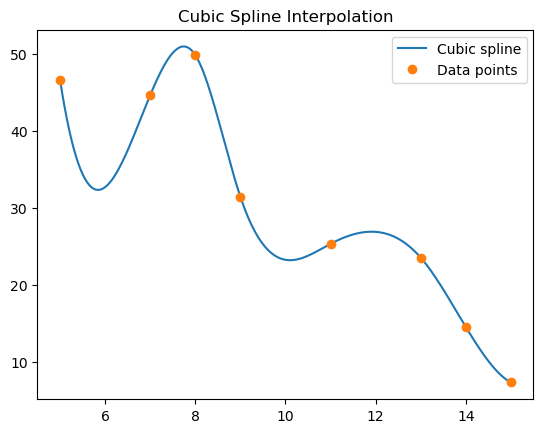

In [35]:
# Use spline to approximate the values in part 1 and 2
from scipy.interpolate import CubicSpline

spline = CubicSpline(xnodes, ynodes)

# Repeate part 1
x_spline = np.linspace(5, 15, 401)
y_spline = spline(x_spline)

# Repeat part 2
y_spline_interpolate = [spline(x) for x in x_interpolate]

plt.plot(x_spline, y_spline, label="Cubic spline")
plt.plot(xnodes, ynodes, "o", label="Data points")
plt.title("Cubic Spline Interpolation")
plt.legend()

for i, value in enumerate(y_spline_interpolate):
    if x_interpolate[i] == 29:
        print(f"Date: March 1, Predicted: {value:.2f}°F")
    else:
        print(
            f"Date: February {x_interpolate[i]}, "
            f"Predicted: {value:.2f}°F"
        )

